###Introduction

PySpark is the Python API for Apache Spark, an open-source big data processing framework. It provides a powerful and scalable platform for data processing and analytics. This notebook will cover the basics of PySpark and guide you through some fundamental concepts and operations.

###1. Installing PySpark


In [10]:
! pip install pySpark

###2. Importing Required Library

In [42]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


###3. Initializing SparkSession

To interact with Spark, we need to create a SparkSession, which serves as the entry point for using PySpark.

In [2]:
spark=SparkSession.builder.appName("Pyspark Basics").getOrCreate()

###4. Loading Data

PySpark supports various data formats, including CSV, JSON, Parquet, and more. Let's see how to load a CSV file into a PySpark DataFrame.

In [36]:
from google.colab import files
uploaded = files.upload()


Saving stocks.txt to stocks (1).txt


In [39]:

# Read a TEXT File
txt_data = spark.read.text("/content/stocks.txt")


###5. Exploring Data

In [41]:
# Display the first few rows of the DataFrame
txt_data.show(truncate=False)

+----------------------------------------+
|value                                   |
+----------------------------------------+
|id,name,category,quantity,price         |
|1,iPhone,Electronics,10,899.99          |
|2,Macbook,Electronics,5,1299.99         |
|3,iPad,Electronics,15,499.99            |
|4,Samsung TV,Electronics,8,799.99       |
|5,LG TV,Electronics,10,699.99           |
|6,Nike Shoes,Clothing,30,99.99          |
|7,Adidas Shoes,Clothing,25,89.99        |
|8,Sony Headphones,Electronics,12,149.99 |
|9,Beats Headphones,Electronics,20,199.99|
|10,Dining Table,Furniture,10,249.99     |
|11,Study Desk,Furniture,8,149.99        |
|12,Apples,Food,100,0.5                  |
|13,Bananas,Food,150,0.25                |
|14,Oranges,Food,120,0.75                |
|15,Chicken Breast,Food,50,3.99          |
|16,Salmon Fillet,Food,30,5.99           |
|17,Leather Jacket,Clothing,15,199.99    |
|18,Winter Coat,Clothing,10,149.99       |
|19,Yoga Mat,Sports,20,19.99             |
+----------

###Convert This Test Data into table or CSV Formate

In [47]:
# Directly Convert to CSV

data = spark.read.csv("/content/stocks.txt", header=True, inferSchema=True)
data.show()

+---+----------------+-----------+--------+-------+
| id|            name|   category|quantity|  price|
+---+----------------+-----------+--------+-------+
|  1|          iPhone|Electronics|      10| 899.99|
|  2|         Macbook|Electronics|       5|1299.99|
|  3|            iPad|Electronics|      15| 499.99|
|  4|      Samsung TV|Electronics|       8| 799.99|
|  5|           LG TV|Electronics|      10| 699.99|
|  6|      Nike Shoes|   Clothing|      30|  99.99|
|  7|    Adidas Shoes|   Clothing|      25|  89.99|
|  8| Sony Headphones|Electronics|      12| 149.99|
|  9|Beats Headphones|Electronics|      20| 199.99|
| 10|    Dining Table|  Furniture|      10| 249.99|
| 11|      Study Desk|  Furniture|       8| 149.99|
| 12|          Apples|       Food|     100|    0.5|
| 13|         Bananas|       Food|     150|   0.25|
| 14|         Oranges|       Food|     120|   0.75|
| 15|  Chicken Breast|       Food|      50|   3.99|
| 16|   Salmon Fillet|       Food|      30|   5.99|
| 17|  Leath

### Displaying Schema

In [48]:
# Display The schema of the DataFrame
data.printSchema()

root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- price: double (nullable = true)



### Row Count

In [49]:
# Count Number of Rows in DataFrame
data.count()

30

### Performing Statistivcal Analysis

In [50]:
# Get Summary of Statistics of Numerical Columns
data.describe().show()

+-------+-----------------+------------+-----------+-----------------+------------------+
|summary|               id|        name|   category|         quantity|             price|
+-------+-----------------+------------+-----------+-----------------+------------------+
|  count|               30|          30|         30|               30|                30|
|   mean|             15.5|        NULL|       NULL|             29.3|227.37433333333317|
| stddev|8.803408430829505|        NULL|       NULL|34.80006936180166|320.66170023533545|
|    min|                1|Adidas Shoes|Accessories|                5|              0.25|
|    max|               30|      iPhone|     Sports|              150|           1299.99|
+-------+-----------------+------------+-----------+-----------------+------------------+



###6. Data Transformation

In [52]:
# Select Specific columns
selected_data= data.select("id","category","quantity")
# Show that Selected Data
selected_data.show()

+---+-----------+--------+
| id|   category|quantity|
+---+-----------+--------+
|  1|Electronics|      10|
|  2|Electronics|       5|
|  3|Electronics|      15|
|  4|Electronics|       8|
|  5|Electronics|      10|
|  6|   Clothing|      30|
|  7|   Clothing|      25|
|  8|Electronics|      12|
|  9|Electronics|      20|
| 10|  Furniture|      10|
| 11|  Furniture|       8|
| 12|       Food|     100|
| 13|       Food|     150|
| 14|       Food|     120|
| 15|       Food|      50|
| 16|       Food|      30|
| 17|   Clothing|      15|
| 18|   Clothing|      10|
| 19|     Sports|      20|
| 20|     Sports|      15|
+---+-----------+--------+
only showing top 20 rows


###Filtering Row based on a condition

In [55]:
filtered_data= data.filter(data['quantity']>50)
filtered_data.show()

+---+-------+--------+--------+-----+
| id|   name|category|quantity|price|
+---+-------+--------+--------+-----+
| 12| Apples|    Food|     100|  0.5|
| 13|Bananas|    Food|     150| 0.25|
| 14|Oranges|    Food|     120| 0.75|
+---+-------+--------+--------+-----+



### Sorting & ranking

In [66]:

# Find Top 5 Expensive Product
top_expensive_products=data.orderBy(data["price"].desc())
top_expensive_products.show(5)

+---+----------+-----------+--------+-------+
| id|      name|   category|quantity|  price|
+---+----------+-----------+--------+-------+
|  2|   Macbook|Electronics|       5|1299.99|
|  1|    iPhone|Electronics|      10| 899.99|
|  4|Samsung TV|Electronics|       8| 799.99|
|  5|     LG TV|Electronics|      10| 699.99|
| 26|    Camera|Electronics|      10| 599.99|
+---+----------+-----------+--------+-------+
only showing top 5 rows


In [23]:

data_with_new_column.describe().show()

+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|summary|       Store ID |        Store_Area|   Items_Available|Daily_Customer_Count|       Store_Sales|Avg_sales_per_person|
+-------+----------------+------------------+------------------+--------------------+------------------+--------------------+
|  count|             896|               896|               896|                 896|               896|                 896|
|   mean|           448.5|1485.4095982142858|1782.0357142857142|   786.3504464285714| 59351.30580357143|   94.04317457240369|
| stddev|258.797217913949|250.23701095319237| 299.8720525241988|  265.38928076727075|17190.741894878298|  162.81909882435673|
|    min|               1|               775|               932|                  10|             14920|  15.070707070707071|
|    max|             896|              2229|              2667|                1560|            116320|              

### Group by Column and Compute Aggregation Function

In [56]:
grouped_data= data.groupBy("category").agg(sum('quantity').alias("Total_quantity"))
grouped_data.show()

+-----------+--------------+
|   category|Total_quantity|
+-----------+--------------+
|       Food|           450|
|     Sports|            35|
|Electronics|            98|
|   Clothing|           200|
|  Furniture|            41|
|Accessories|            55|
+-----------+--------------+



##7. Data Agrregation

In [60]:
# Compute the average of a column
average_value=data.groupBy("category").agg(avg("price").alias("avg_price"))
average_value.show()

+-----------+------------------+
|   category|         avg_price|
+-----------+------------------+
|       Food|2.2960000000000003|
|     Sports|             34.99|
|Electronics| 586.6566666666665|
|   Clothing|  99.2757142857143|
|  Furniture|            141.99|
|Accessories|             27.49|
+-----------+------------------+



##8. Data Visualization

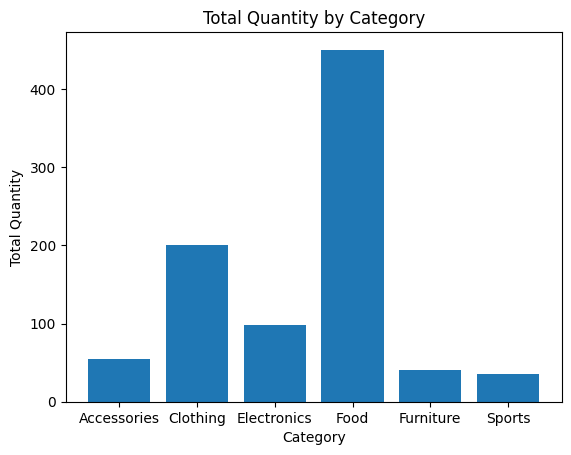

In [77]:
# Convert Spark DataFrame to Pandas
pandas_data = data.toPandas()

# Group by category and sum quantity
category_quantity = pandas_data.groupby("category", as_index=False)["quantity"].sum()

# Create a Bar
plt.bar(category_quantity["category"], category_quantity["quantity"])
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.title("Total Quantity by Category")
plt.show()

###9. writing Data

In [78]:
data.write.parquet("stocks_output.parquet")
print("Done")

Done
